In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np

data=np.load('/content/drive/MyDrive/Innodata/Skin/Files/data.npy')
target=np.load('/content/drive/MyDrive/Innodata/Skin/Files/target.npy')

#loading the save numpy arrays in the previous code

In [3]:
from keras.models import Sequential
from keras.layers import Dense,Activation,Flatten,Dropout
from keras.layers import Conv2D,MaxPooling2D

model=Sequential()

model.add(Conv2D(256,(3,3),input_shape=data.shape[1:]))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
#The first CNN layer followed by Relu and MaxPooling layers

model.add(Conv2D(128,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
#The second convolution layer followed by Relu and MaxPooling layers

model.add(Flatten())
model.add(Dropout(0.5))
#Flatten layer to stack the output convolutions from second convolution layer
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
#Dense layer of 64 neurons
model.add(Dense(10,activation='softmax'))
#The Final layer with two outputs for two categories

model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [4]:
from sklearn.model_selection import train_test_split

train_data,test_data,train_target,test_target=train_test_split(data,target,test_size=0.3)

In [5]:
history=model.fit(train_data,train_target,epochs=30,validation_split=0.1)

Epoch 1/30
10/10 [==============================] - 11s 989ms/step - loss: 1.8799 - accuracy: 0.3232 - val_loss: 1.4249 - val_accuracy: 0.3636
Epoch 2/30
10/10 [==============================] - 8s 767ms/step - loss: 1.7332 - accuracy: 0.3333 - val_loss: 1.3622 - val_accuracy: 0.3636
Epoch 3/30
10/10 [==============================] - 11s 1s/step - loss: 1.6607 - accuracy: 0.3569 - val_loss: 1.3731 - val_accuracy: 0.3636
Epoch 4/30
10/10 [==============================] - 9s 957ms/step - loss: 1.6508 - accuracy: 0.3670 - val_loss: 1.3071 - val_accuracy: 0.3636
Epoch 5/30
10/10 [==============================] - 7s 735ms/step - loss: 1.6179 - accuracy: 0.3636 - val_loss: 1.3974 - val_accuracy: 0.3636
Epoch 6/30
10/10 [==============================] - 9s 964ms/step - loss: 1.5442 - accuracy: 0.3569 - val_loss: 1.2977 - val_accuracy: 0.3636
Epoch 7/30
10/10 [==============================] - 9s 873ms/step - loss: 1.4937 - accuracy: 0.3805 - val_loss: 1.2339 - val_accuracy: 0.5152
Epoch 8

Text(0, 0.5, 'loss')

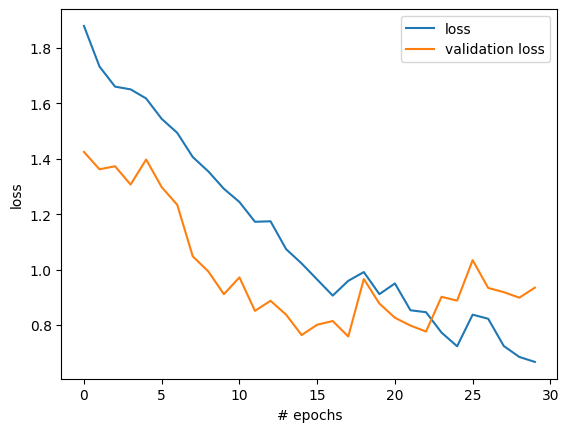

In [6]:
from matplotlib import pyplot as plt

plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.legend()
plt.xlabel('# epochs')
plt.ylabel('loss')

Text(0, 0.5, 'accuracy')

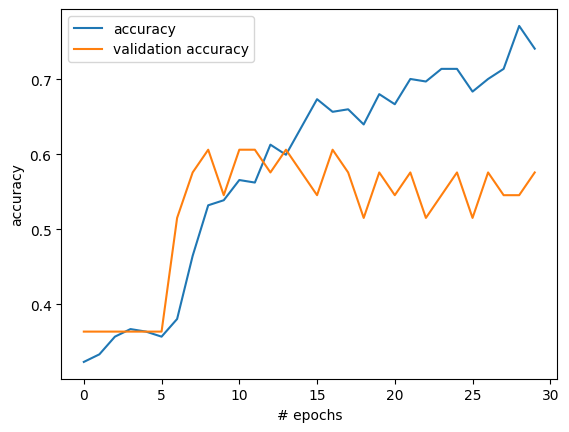

In [7]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.legend()
plt.xlabel('# epochs')
plt.ylabel('accuracy')
#if not working replace 'accuracy' with 'acc'

In [8]:
print(model.evaluate(test_data,test_target))

5/5 [==============================] - 1s 181ms/step - loss: 1.1189 - accuracy: 0.5845
[1.1189435720443726, 0.5845070481300354]


In [9]:
model.save_weights('/content/drive/MyDrive/Innodata/Skin/Files/skin_color.h5')